# Credit Risk Probability Model - Exploratory Data Analysis

## Objective
The objective of this notebook is to explore the Xente transaction dataset, understand data quality, identify patterns, analyze feature distributions, and generate insights that guide feature engineering and credit risk modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [2]:
definitions = pd.read_csv("../data/raw/Xente_Variable_Definitions.csv")

definitions.head()

,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account


# 1. Data Overview

In [3]:
df.shape

(95662, 16)

In [4]:
# column names
df.columns

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')

In [5]:
# Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

# 2. Summary Statistics

In [6]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [7]:
df.describe(include='object')

C:\Users\Lenovo T480s\AppData\Local\Temp\ipykernel_7860\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId,TransactionStartTime
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4,94556
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3,2018-12-24T16:30:13Z
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935,17


# 3. Missing Values

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

# 4. Numerical Feature Distributions

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns

numerical_cols

Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

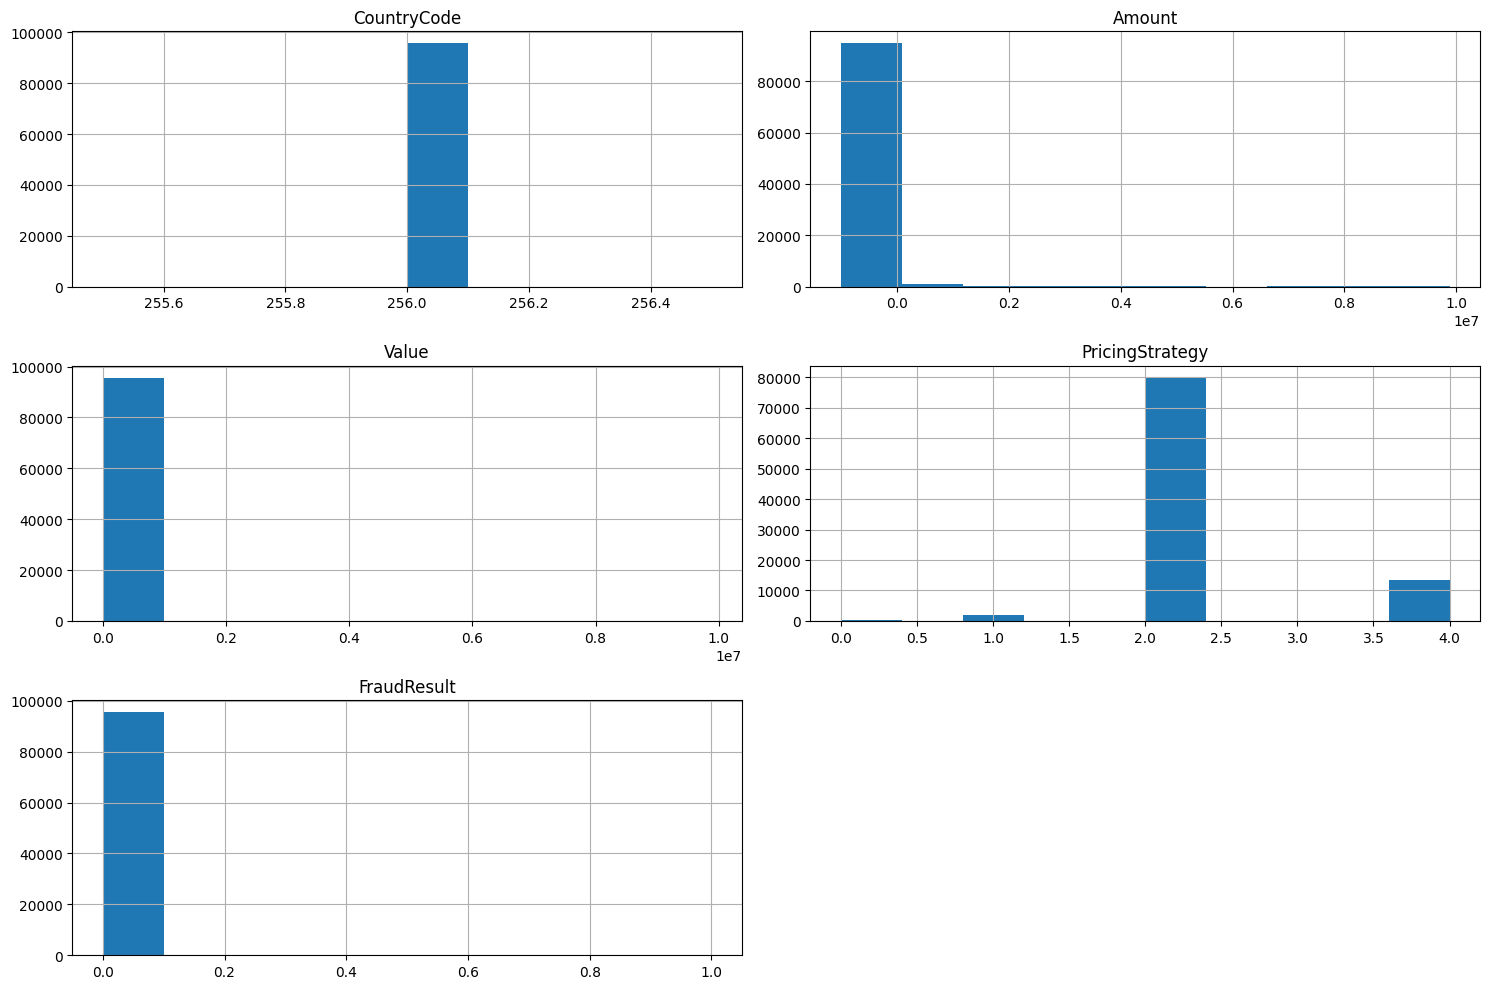

In [10]:
df[numerical_cols].hist(figsize=(15, 10))

plt.tight_layout()
plt.show()

# 5. Categorical Feature Distributions

In [11]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

C:\Users\Lenovo T480s\AppData\Local\Temp\ipykernel_7860\2424776929.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory',
       'ChannelId', 'TransactionStartTime'],
      dtype='str')

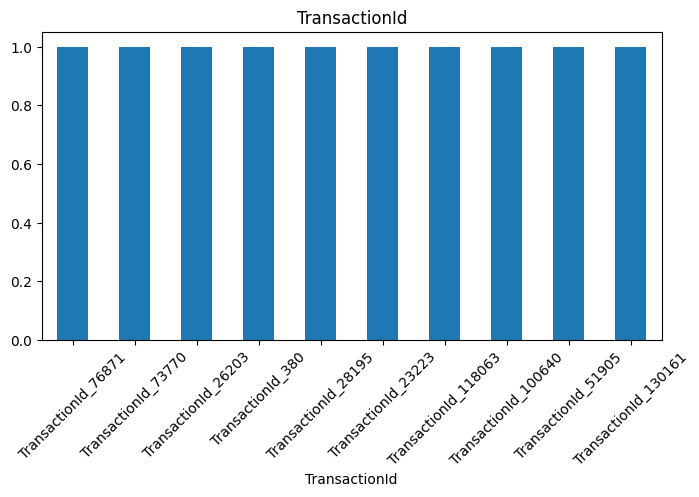

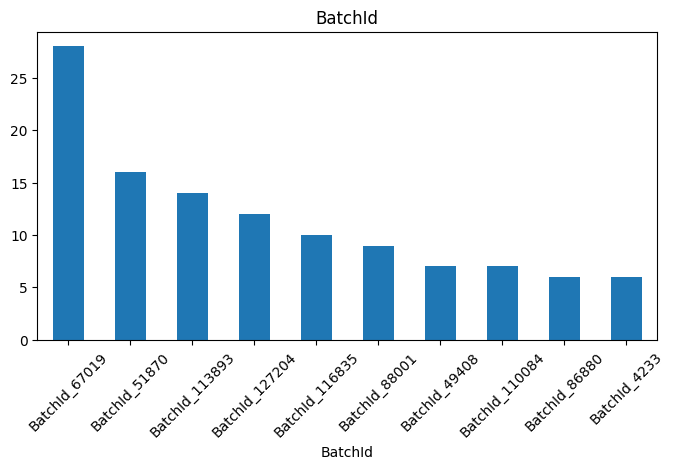

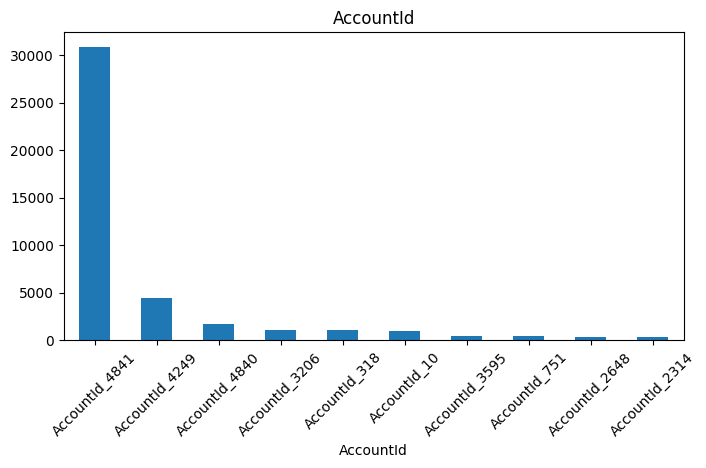

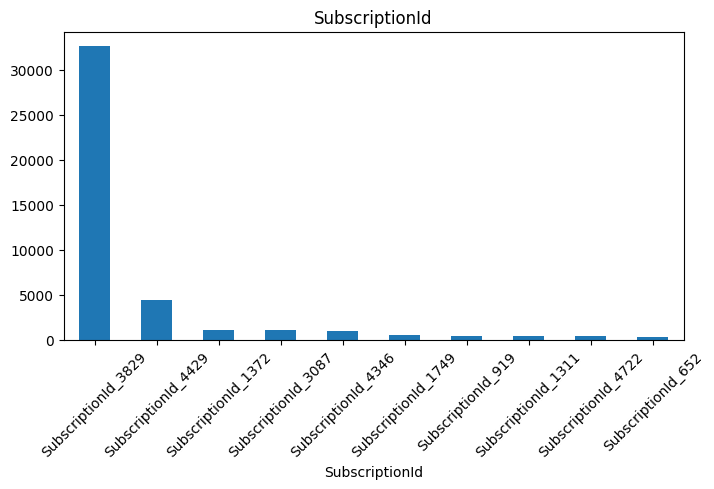

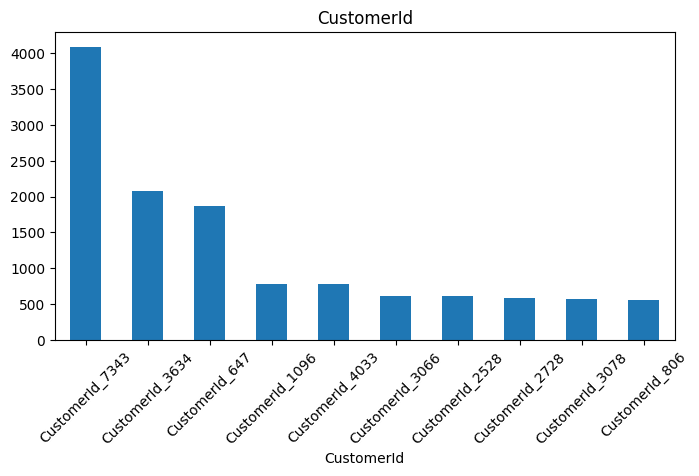

In [12]:
for col in categorical_cols[:5]:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

# 6. Correlation Analysis

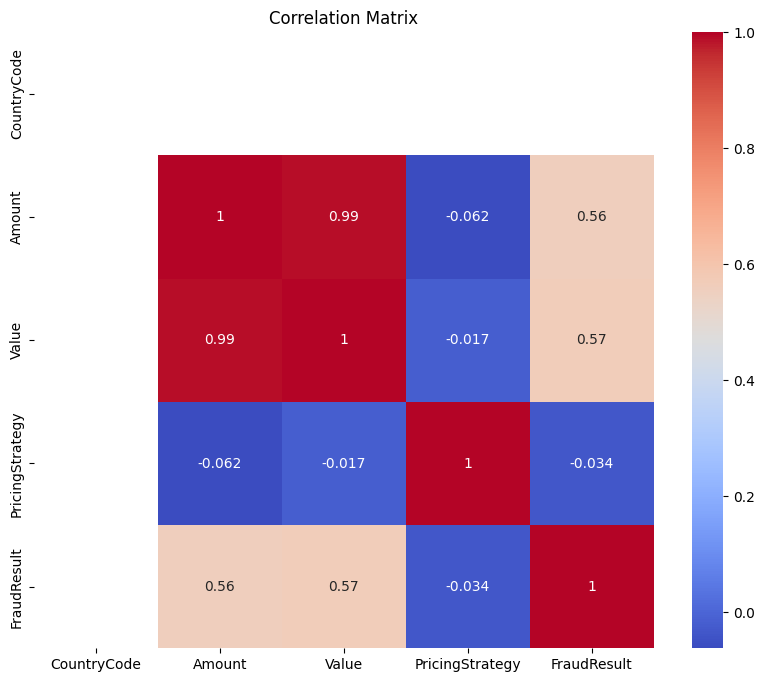

In [13]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# 7. Outlier Detection

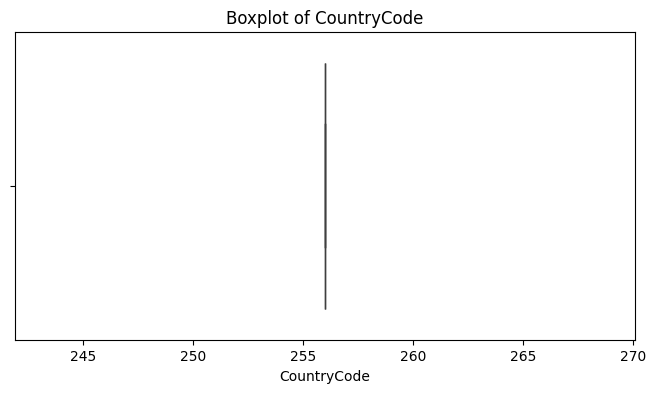

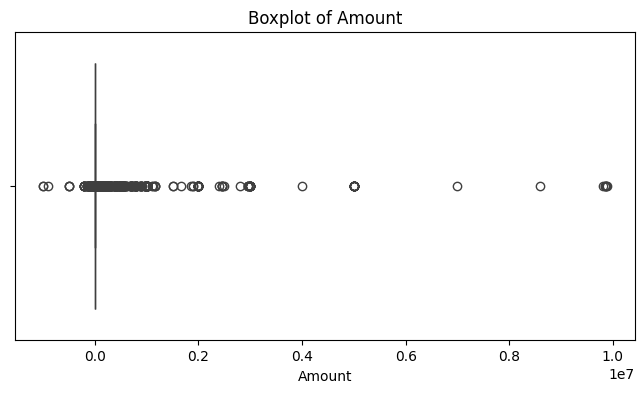

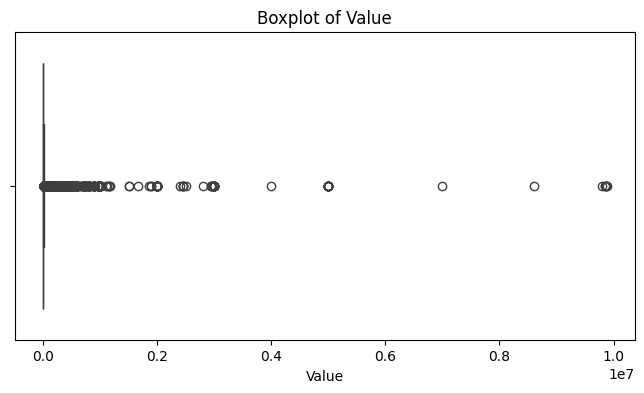

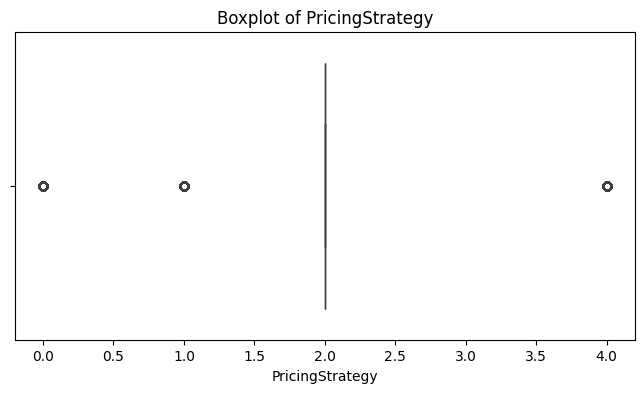

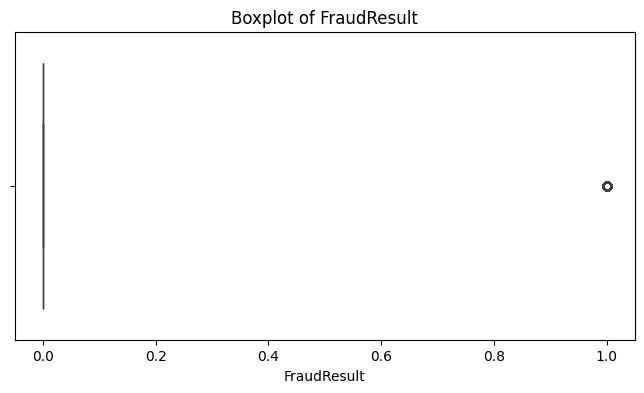

In [14]:
for col in numerical_cols[:5]:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

# 8. Key Insights

1. The dataset contains both numerical and categorical features that require preprocessing before modeling.

2. Several numerical features show skewed distributions and contain outliers, indicating the need for scaling and robust feature engineering.

3. Transaction-related behavioral features appear highly valuable for customer risk profiling and RFM analysis.

4. Some categorical variables contain high-cardinality categories, which may require careful encoding strategies.

5. Correlation analysis suggests relationships among transaction and value-related features that may influence credit risk prediction.

# Dataset Preview
The first few rows of the dataset are displayed below to understand the structure and contents of the transaction records.

In [15]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [16]:
df.sample(5)

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
1985,TransactionId_46501,BatchId_107676,AccountId_331,SubscriptionId_2842,CustomerId_661,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-16T18:17:16Z,2,0
90661,TransactionId_107524,BatchId_112066,AccountId_4792,SubscriptionId_2592,CustomerId_5261,UGX,256,ProviderId_1,ProductId_10,airtime,ChannelId_3,10000.0,10000,2019-02-08T17:02:49Z,4,0
94018,TransactionId_105430,BatchId_60692,AccountId_4022,SubscriptionId_3478,CustomerId_4472,UGX,256,ProviderId_6,ProductId_3,airtime,ChannelId_3,1000.0,1000,2019-02-11T18:42:06Z,2,0
49558,TransactionId_30534,BatchId_128649,AccountId_3027,SubscriptionId_3197,CustomerId_3452,UGX,256,ProviderId_6,ProductId_3,airtime,ChannelId_3,3000.0,3000,2019-01-03T08:23:47Z,2,0
39820,TransactionId_92297,BatchId_23448,AccountId_3206,SubscriptionId_1372,CustomerId_3634,UGX,256,ProviderId_6,ProductId_3,airtime,ChannelId_3,2000.0,2000,2018-12-25T08:02:48Z,2,0


# Duplicate Records Analysis

In [17]:
df.duplicated().sum()

np.int64(0)

This checks whether duplicate transaction records exist in the dataset.

# Transaction Time Processing

In [18]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

df["TransactionStartTime"].head()

0   2018-11-15 02:18:49+00:00
1   2018-11-15 02:19:08+00:00
2   2018-11-15 02:44:21+00:00
3   2018-11-15 03:32:55+00:00
4   2018-11-15 03:34:21+00:00
Name: TransactionStartTime, dtype: datetime64[us, UTC]

In [19]:
df["transaction_hour"] = df["TransactionStartTime"].dt.hour
df["transaction_day"] = df["TransactionStartTime"].dt.day
df["transaction_month"] = df["TransactionStartTime"].dt.month
df["transaction_year"] = df["TransactionStartTime"].dt.year

df[[
    "transaction_hour",
    "transaction_day",
    "transaction_month",
    "transaction_year"
]].head()

,transaction_hour,transaction_day,transaction_month,transaction_year
0,2,15,11,2018
1,2,15,11,2018
2,2,15,11,2018
3,3,15,11,2018
4,3,15,11,2018


# Fraud Distribution Analysis

In [20]:
df["FraudResult"].value_counts()

FraudResult
0    95469
1      193
Name: count, dtype: int64

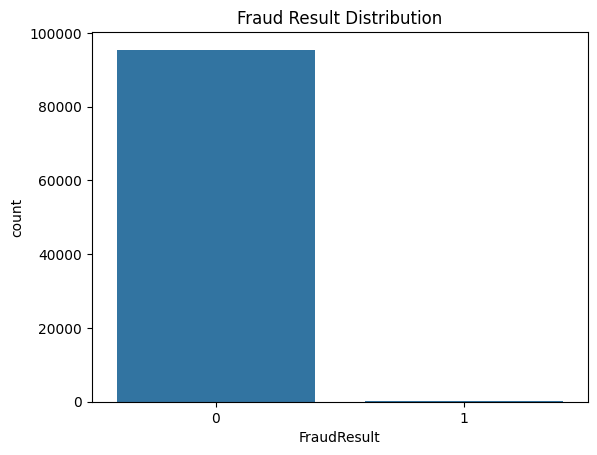

In [21]:
sns.countplot(x="FraudResult", data=df)

plt.title("Fraud Result Distribution")

plt.show()

# Transaction Amount Analysis

In [22]:
df["Amount"].describe()

count    9.566200e+04
mean     6.717846e+03
std      1.233068e+05
min     -1.000000e+06
25%     -5.000000e+01
50%      1.000000e+03
75%      2.800000e+03
max      9.880000e+06
Name: Amount, dtype: float64

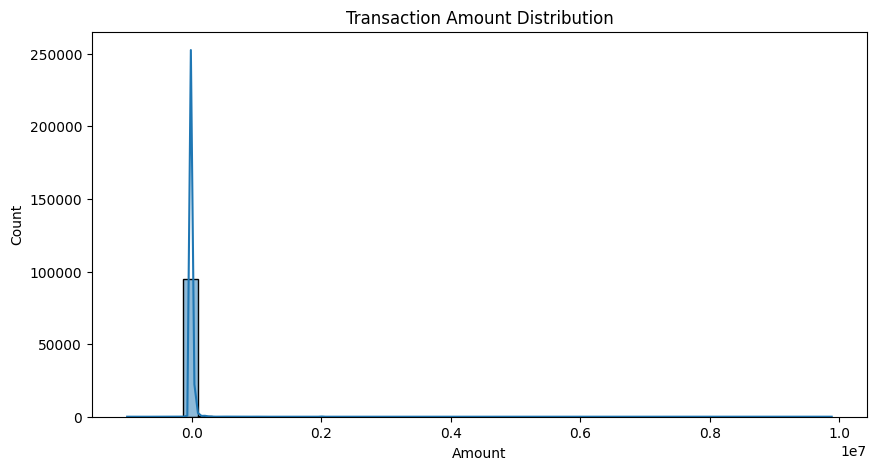

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Amount"], bins=50, kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

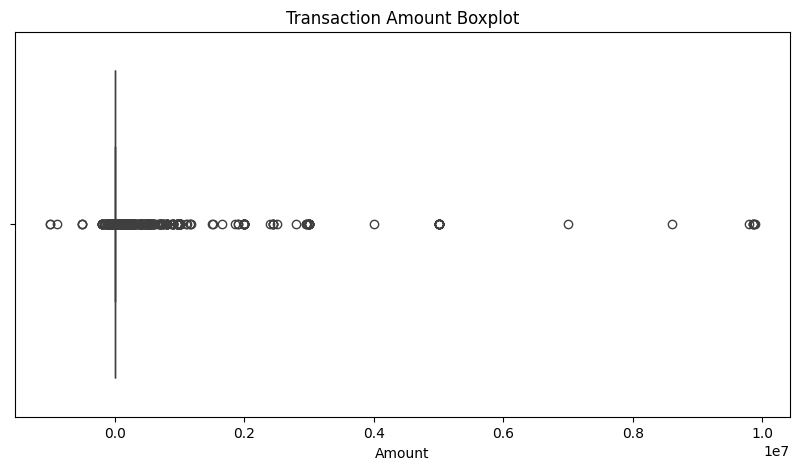

In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Amount"])

plt.title("Transaction Amount Boxplot")

plt.show()

# Customer Transaction Behavior

In [25]:
customer_transaction_count = df["CustomerId"].value_counts()

customer_transaction_count.head()

CustomerId
CustomerId_7343    4091
CustomerId_3634    2085
CustomerId_647     1869
CustomerId_1096     784
CustomerId_4033     778
Name: count, dtype: int64

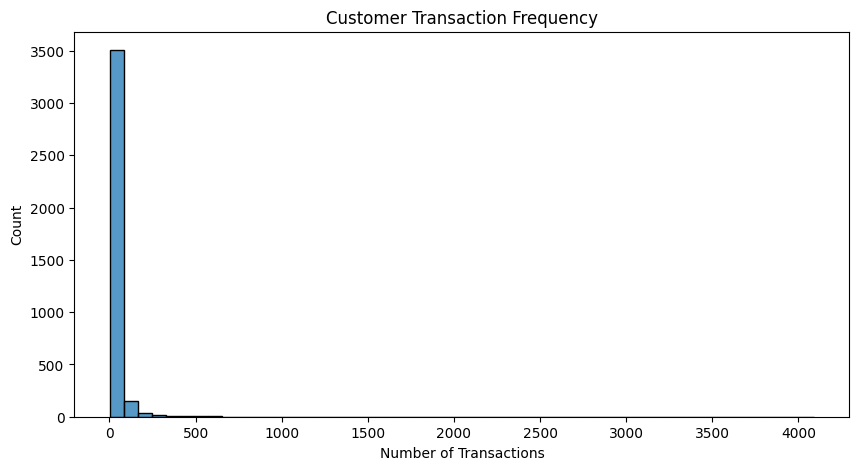

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(customer_transaction_count, bins=50)

plt.title("Customer Transaction Frequency")

plt.xlabel("Number of Transactions")

plt.show()

# Final EDA Insights

## Key Findings

1. The dataset contains a mixture of numerical, categorical, and datetime variables that require preprocessing before machine learning modeling.

2. Transaction amount features are highly skewed and contain significant outliers, indicating that normalization or standardization techniques may be necessary.

3. Fraud outcomes are heavily imbalanced, suggesting that evaluation metrics beyond accuracy, such as ROC-AUC and F1-score, will be important during model evaluation.

4. Customer transaction behavior varies significantly across users, supporting the usefulness of behavioral segmentation techniques such as RFM analysis.

5. Temporal transaction patterns extracted from transaction timestamps may provide valuable predictive signals for customer credit risk modeling.

6. Several categorical variables contain many unique categories, which may require encoding strategies such as one-hot encoding or Weight of Evidence (WoE) transformation.

7. The dataset appears relatively clean with limited missing values, which simplifies preprocessing and improves modeling reliability.

# RFM Customer Segmentation

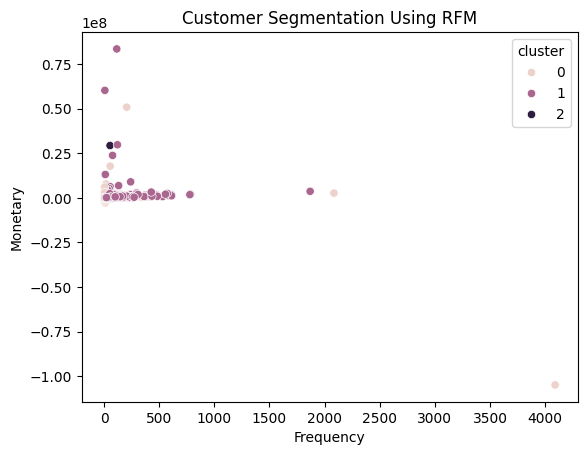

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

rfm = (
    df.groupby("CustomerId")
    .agg(
        Recency=(
            "TransactionStartTime",
            lambda x: (
                pd.to_datetime(df["TransactionStartTime"]).max()
                - pd.to_datetime(x).max()
            ).days,
        ),
        Frequency=("TransactionId", "count"),
        Monetary=("Amount", "sum"),
    )
    .reset_index()
)

scaler = MinMaxScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10,
)

rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

sns.scatterplot(
    x=rfm["Frequency"],
    y=rfm["Monetary"],
    hue=rfm["cluster"],
)

plt.title("Customer Segmentation Using RFM")

plt.show()